In [ ]:
from pathlib import Path
import wfdb
import numpy as np

subject_dir = Path(r"/home/charlotte/Documents/Tesi/Motoneuron_Synergies_Driven_Gesture_Prediction/glove_sample_subj_01_trial_01")

# Record WFDB: .hea (header) and .dat (dati).
hea_files = sorted(subject_dir.glob("*.hea"))
print("File .hea trovati:")
for f in hea_files:
    print(f.name)

# Choose the first .hea file (assuming there's only one record per trial)
record_base = hea_files[0].with_suffix("")  

# Read record: wfdb load automatically the .dat file
rec = wfdb.rdrecord(str(record_base))

print("\nName Angles Glove:")
for i, name in enumerate(rec.sig_name):
    print(i, name)

data = rec.p_signal
print("\nShape dati:", data.shape)
print("Sampling Frequency:", rec.fs)

File .hea trovati:
hdkw_kin_exp03_subj01_1_glove.hea

Nomi canali / segnali nel file:
0 TN
1 TF
2 T&I
3 IN
4 IF
5 I&M
6 MN
7 MF
8 M&R
9 RN
10 RF
11 R&P
12 PN
13 PF

Shape dati: (37400, 14)
Frequenza di campionamento: 2000

Primi 5 campioni del primo canale:
[2511. 2511. 2511. 2511. 2512.]

Primi 5 campioni dei primi 3 canali:
[[2511. 2787. 3125.]
 [2511. 2787. 3125.]
 [2511. 2787. 3125.]
 [2511. 2787. 3125.]
 [2512. 2786. 3125.]]


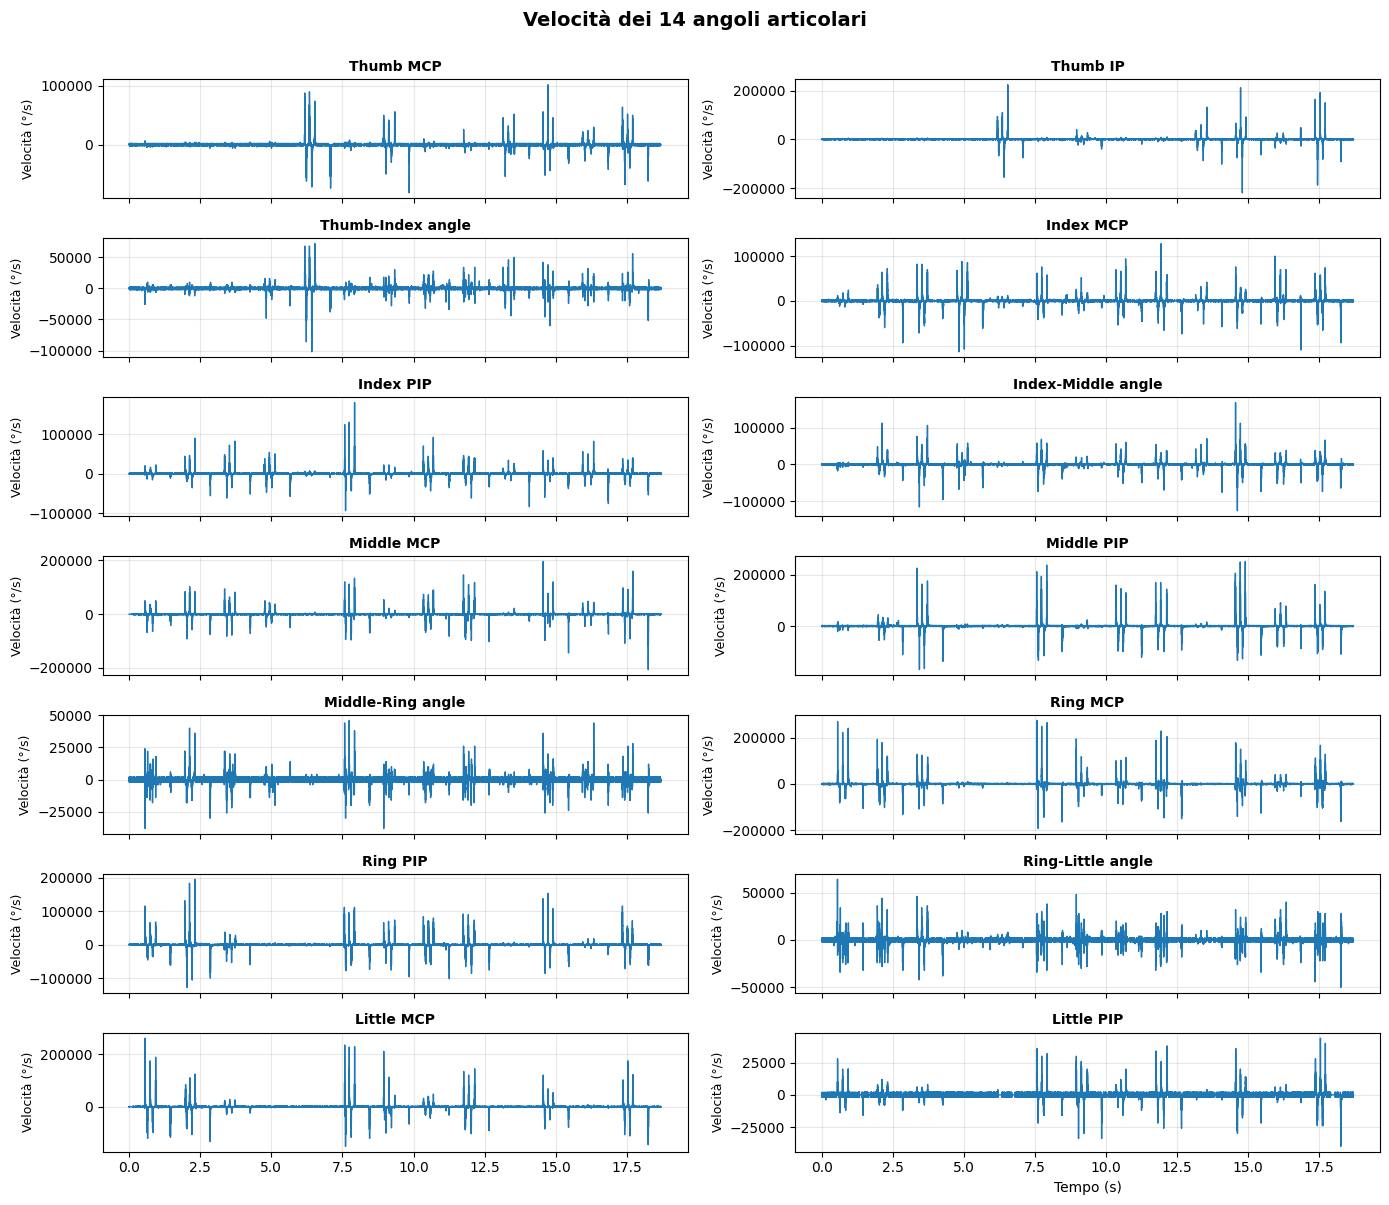

Durata totale: 18.70 secondi
Numero campioni velocità: 37399


In [2]:
import matplotlib.pyplot as plt

# Calcolo velocità (derivata degli angoli)
fs = rec.fs  # 200 Hz
dt = 1 / fs
velocities = np.diff(data, axis=0) / dt

# Tempo in secondi
time = np.arange(velocities.shape[0]) / fs

# Mappatura canali
channel_names = [
    "Thumb MCP", "Thumb IP", "Thumb-Index angle",
    "Index MCP", "Index PIP", "Index-Middle angle",
    "Middle MCP", "Middle PIP", "Middle-Ring angle",
    "Ring MCP", "Ring PIP", "Ring-Little angle",
    "Little MCP", "Little PIP"
]

# Plot: velocità di ogni angolo
fig, axes = plt.subplots(7, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

for ch in range(14):
    axes[ch].plot(time, velocities[:, ch], linewidth=1)
    axes[ch].set_title(channel_names[ch], fontsize=10, fontweight='bold')
    axes[ch].set_ylabel('Velocità (°/s)', fontsize=9)
    axes[ch].grid(True, alpha=0.3)

axes[-1].set_xlabel('Tempo (s)', fontsize=10)
plt.suptitle('Velocità dei 14 angoli articolari', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"Durata totale: {time[-1]:.2f} secondi")
print(f"Numero campioni velocità: {velocities.shape[0]}")